## **Quel projet choisir ?**

Voici les étapes :

1. Choix de notre base de données. 
(Il s'agit de l'ensemble de données abordé dans la conférence « Comment embaucher et tester les compétences en matière de données : un kit d'entretien universel » de conférence oreilly)
"Fondée en 1996, BeerAdvocate est la ressource incontournable en matière de bière pour des millions de consommateurs chaque mois. La référence en matière de critiques de bière et la voix des passionnés de bière."
--> Cet ensemble de données comprend 1.5 millions de critiques de bières de beeradvocate. Les données couvrent une période de janv. 1998 à novembre 2011. 
--> Chaque critique comprend des notes en fonction de cinq « aspects » : l'apparence, l'arôme, le palais, le goût et l'impression générale. Les notes vont de 0 à 5.
Les critiques comprennent également des informations sur le produit et l'utilisateur, en texte brut. 

https://www.kaggle.com/datasets/rdoume/beerreviews/data 

2. Mes interrogations

**—> Quel type de bière est plus plébscité qu'un autre ?**

**-> Quelle est LA meilleure bière ?**

**->si je devais choisir 5 bières parmis le jeu de données, lesquelles seraient elles ?**

**-> A partir de mes goûts, quelle serait la bière qui pourrait m'être conseillée selon beeradovcate ?**

METHODOLOGIE
1. Explorez votre base de données et réalisez des statistiques descriptives via Tableau, construisez des intervalles de confiance si nécessaire.
2. Appliquez un modèle d’apprentissage automatique appris en classe qui peut vous aider à résoudre votre problème.
3. Formatez vos résultats à l'aide de Tableau ou Python.
4. Amusez-vous!

# Import des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

path_to_file="D:/Profils/NLefort/Desktop/JEDHA/Essential/Data_essential_project"

In [2]:
df=pd.read_csv(path_to_file+"/beer_reviews.csv")

## Analyse descriptive rapide

In [3]:
#Aperçu rapide des données
#mon review_time doit probablement m'afficher des dates/heures mais je sais pas trop sous quel format
df.head()


,brewery_id,brewery_name,review_time,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
0,10325,Vecchio Birraio,1234817823,1.5,2.0,2.5,stcules,Hefeweizen,1.5,1.5,Sausa Weizen,5.0,47986
1,10325,Vecchio Birraio,1235915097,3.0,2.5,3.0,stcules,English Strong Ale,3.0,3.0,Red Moon,6.2,48213
2,10325,Vecchio Birraio,1235916604,3.0,2.5,3.0,stcules,Foreign / Export Stout,3.0,3.0,Black Horse Black Beer,6.5,48215
3,10325,Vecchio Birraio,1234725145,3.0,3.0,3.5,stcules,German Pilsener,2.5,3.0,Sausa Pils,5.0,47969
4,1075,Caldera Brewing Company,1293735206,4.0,4.5,4.0,johnmichaelsen,American Double / Imperial IPA,4.0,4.5,Cauldron DIPA,7.7,64883


In [4]:
df.info() #format de mes données

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1586614 entries, 0 to 1586613
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   brewery_id          1586614 non-null  int64  
 1   brewery_name        1586599 non-null  object 
 2   review_time         1586614 non-null  int64  
 3   review_overall      1586614 non-null  float64
 4   review_aroma        1586614 non-null  float64
 5   review_appearance   1586614 non-null  float64
 6   review_profilename  1586266 non-null  object 
 7   beer_style          1586614 non-null  object 
 8   review_palate       1586614 non-null  float64
 9   review_taste        1586614 non-null  float64
 10  beer_name           1586614 non-null  object 
 11  beer_abv            1518829 non-null  float64
 12  beer_beerid         1586614 non-null  int64  
dtypes: float64(6), int64(3), object(4)
memory usage: 157.4+ MB


• 13 variables

• dont 6, variables quantitatives

• dont 4, variables qualitatives

• dont 3, variables quantitatives (ID, heure d'enregistrement)

In [ ]:
#est ce que j'ai des valeurs nulles ?
#j'ai 348 lignes pour lesquelles je n'ai pas de testeur et 15 lignes pour lesquelles je n'ai pas de nom de bières
print(df.isnull().sum())

brewery_id                0
brewery_name             15
review_time               0
review_overall            0
review_aroma              0
review_appearance         0
review_profilename      348
beer_style                0
review_palate             0
review_taste              0
beer_name                 0
beer_abv              67785
beer_beerid               0
dtype: int64


• Nettoyage des valeurs...

In [6]:
#gestion des valeurs manquantes
#dropna = supprimer valeur manquantes subset = du sous ensemble ...
df = df.dropna(subset=['brewery_name', 'review_profilename', "beer_abv"])

• Enlever les doublons

In [7]:
df = df.drop_duplicates(subset= ['review_profilename','beer_name'], keep='first')

df.info()

print("Percent of Duplicate Values:", round((1586614 - 1561390)/ 586614 * 100, 2),"%")

<class 'pandas.core.frame.DataFrame'>
Index: 1496263 entries, 0 to 1586613
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   brewery_id          1496263 non-null  int64  
 1   brewery_name        1496263 non-null  object 
 2   review_time         1496263 non-null  int64  
 3   review_overall      1496263 non-null  float64
 4   review_aroma        1496263 non-null  float64
 5   review_appearance   1496263 non-null  float64
 6   review_profilename  1496263 non-null  object 
 7   beer_style          1496263 non-null  object 
 8   review_palate       1496263 non-null  float64
 9   review_taste        1496263 non-null  float64
 10  beer_name           1496263 non-null  object 
 11  beer_abv            1496263 non-null  float64
 12  beer_beerid         1496263 non-null  int64  
dtypes: float64(6), int64(3), object(4)
memory usage: 159.8+ MB
Percent of Duplicate Values: 4.3 %


• 4.3% de mon échantillon était des valeurs doublons

# Principaux éléments du dataset variables quantitatives
- Moyenne (mean)

- Médiane (50%)

- Minimum (min)

- Maximum (max)

- Écart-type (std)

- Quartiles (25% et 75%)

In [8]:
df.describe().round(2)

,brewery_id,review_time,review_overall,review_aroma,review_appearance,review_palate,review_taste,beer_abv,beer_beerid
count,1496263.00,1.496263e+06,1496263.00,1496263.00,1496263.00,1496263.00,1496263.00,1496263.00,1496263.00
mean,3068.15,1.225593e+09,3.82,3.75,3.85,3.75,3.80,7.05,21434.49
std,5540.52,7.572180e+07,0.72,0.70,0.61,0.68,0.73,2.33,21798.31
min,1.00,8.843904e+08,0.00,1.00,0.00,1.00,1.00,0.01,5.00
25%,141.00,1.175915e+09,3.50,3.50,3.50,3.50,3.50,5.20,1655.00
50%,414.00,1.240608e+09,4.00,4.00,4.00,4.00,4.00,6.50,12895.00
75%,2250.00,1.289257e+09,4.50,4.00,4.00,4.00,4.50,8.50,39273.00
max,28003.00,1.326285e+09,5.00,5.00,5.00,5.00,5.00,57.70,77316.00


• En moyenne,

• Note générale : 3.82/5 (avec des valeurs à 0)

• Note arôme : 3.74/5

• Note apparence : 3.84/5 (avec des valeurs à 0)

• Note palais : 3.79/5

• Note goût : 3.79/5

• Ecart-type à la moyenne compris entre 0.62 et 0.73 --> en moyenne je suis écarte de 0.62 à 0.73 pts par rapport à la moyenne.

• 68% de mon échantillon est compris entre note générale de 3.82 +/- 0.72

• Degré d'alcool moyen : 7.04° 

• 68% de mon échantillon est compris entre avec un degré d'alcool de 7.04 +/- 2.32


• distribution des valeurs

<Axes: >

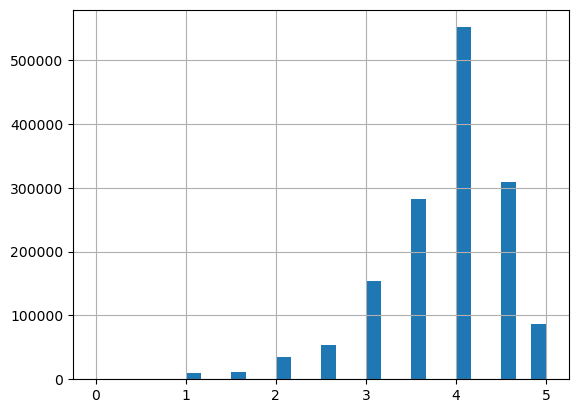

In [9]:
df.review_overall.hist(bins=30)

<Axes: >

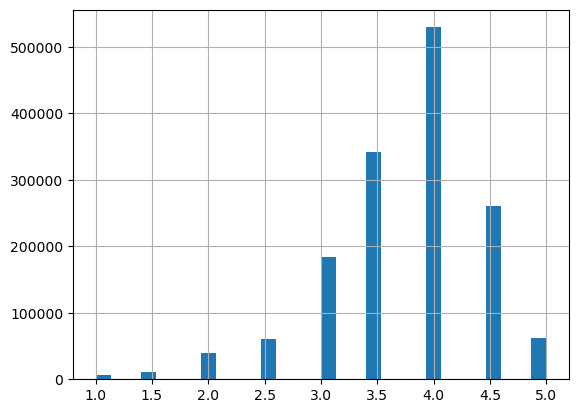

In [10]:
df.review_aroma.hist(bins=30)

<Axes: >

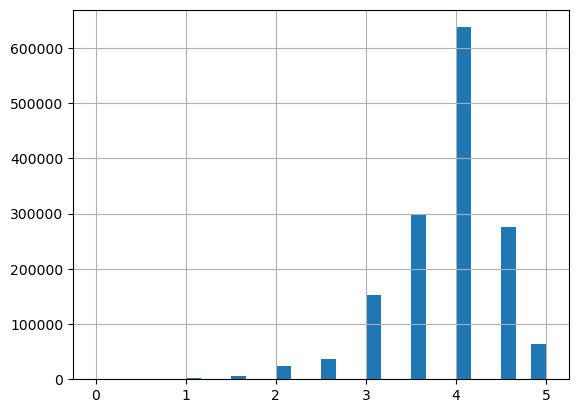

In [11]:
df.review_appearance.hist(bins=30)

<Axes: >

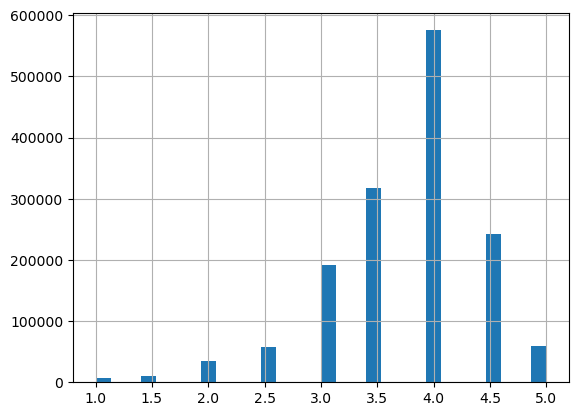

In [12]:
df.review_palate.hist(bins=30)

<Axes: >

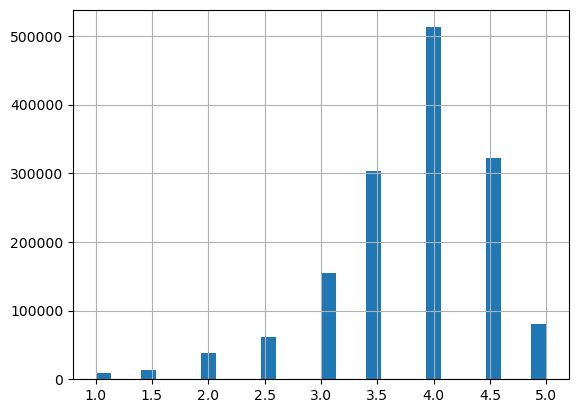

In [13]:
df.review_taste.hist(bins=30)

<Axes: >

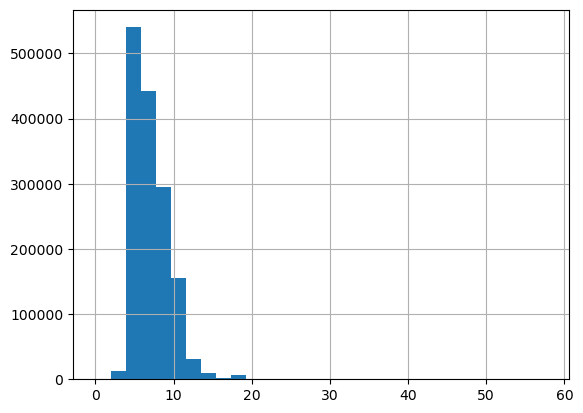

In [14]:
df.beer_abv.hist(bins=30)

<Axes: >

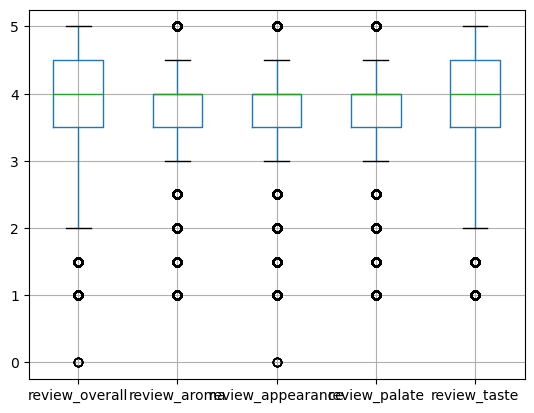

In [15]:
df.boxplot(column=["review_overall","review_aroma", "review_appearance", "review_palate", "review_taste"])

• Commentaires sur les variables quantitatives



In [16]:
print(df['review_profilename'].value_counts()) #identifier les testeurs uniques = 33 387 testeurs

review_profilename
northyorksammy    5177
BuckeyeNation     4144
mikesgroove       4130
Thorpe429         3228
womencantsail     3115
                  ... 
chapcat              1
RudeDog              1
JMooLaH              1
adamrk               1
Scottnr88            1
Name: count, Length: 32908, dtype: int64


• 33 387 ayant un ID différents

In [17]:
print(df['beer_beerid'].value_counts()) #identifier le nombre de bières testées = 66 040 bières testées

beer_beerid
2093     3206
412      3038
1904     2929
4083     2644
92       2633
         ... 
67252       1
58020       1
46581       1
30281       1
47986       1
Name: count, Length: 48656, dtype: int64


• 66 040 bières testées

In [18]:
print(df['beer_style'].value_counts()) # identifier le style de bière testé = 104 styles de bières testés

beer_style
American IPA                        110425
American Double / Imperial IPA       83632
American Pale Ale (APA)              56752
Russian Imperial Stout               52355
American Double / Imperial Stout     49214
                                     ...  
English Pale Mild Ale                  642
Faro                                   606
Roggenbier                             390
Happoshu                               237
Kvass                                  227
Name: count, Length: 104, dtype: int64


• 104 styles de bières testés

In [19]:
print(df['brewery_name'].value_counts()) # identifier le style de bière testé = 104 styles de bières testés

brewery_name
Boston Beer Company (Samuel Adams)                    38533
Dogfish Head Brewery                                  33339
Stone Brewing Co.                                     32525
Sierra Nevada Brewing Co.                             28237
Bell's Brewery, Inc.                                  24610
                                                      ...  
Giessener Brauhaus                                        1
Brasserie Henri Monier                                    1
Pivobezalkogolniy Zavod Severskovo Pischekombinata        1
Alt-Oberurseler Brauhaus                                  1
Brasserie De Lautène                                      1
Name: count, Length: 5135, dtype: int64


# Top 10 des styles de bières les plus testées

beer_style
American IPA                        117566
American Double / Imperial IPA       85958
American Pale Ale (APA)              63460
Russian Imperial Stout               54120
American Double / Imperial Stout     50696
American Porter                      50473
American Amber / Red Ale             45740
Belgian Strong Dark Ale              37731
Fruit / Vegetable Beer               33859
American Strong Ale                  31938
Name: count, dtype: int64


<Axes: ylabel='beer_style'>

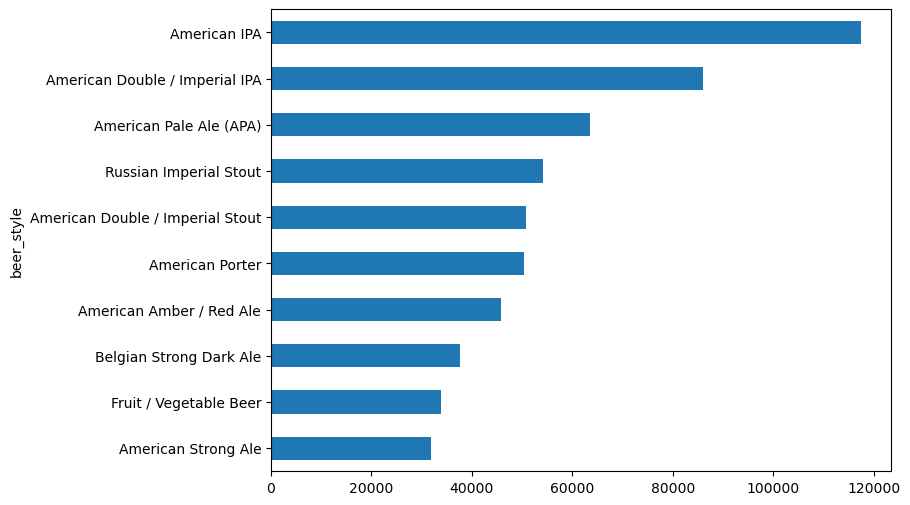

In [18]:
#style de bière les plus testées
beer_styles = df['beer_style'].value_counts().nlargest(n=10)
print(beer_styles)

plt.figure(figsize=(8,6))
beer_styles_top_n = df['beer_style'].value_counts().nlargest(n=10)
beer_styles_top_n.sort_values(inplace=True)
beer_styles_top_n.plot.barh()

In [23]:
review_counts = df['beer_style'].value_counts().reset_index()
review_counts.columns = ['beer_style', 'count']

fig = px.bar(review_counts, x='beer_style', y='count', title='Number of ratings by beer style',
             labels={'count':'Number of ratings', 'beer_style':'Beer style'})
fig.update_xaxes(range=[0,50])
fig.show()

# Top 10 des styles de bières les plus testés

beer_name
90 Minute IPA                          3289
India Pale Ale                         3130
Old Rasputin Russian Imperial Stout    3110
Sierra Nevada Celebration Ale          2999
Two Hearted Ale                        2727
Arrogant Bastard Ale                   2702
Stone Ruination IPA                    2702
Sierra Nevada Pale Ale                 2587
Stone IPA (India Pale Ale)             2574
Pliny The Elder                        2527
Name: count, dtype: int64


<Axes: ylabel='beer_name'>

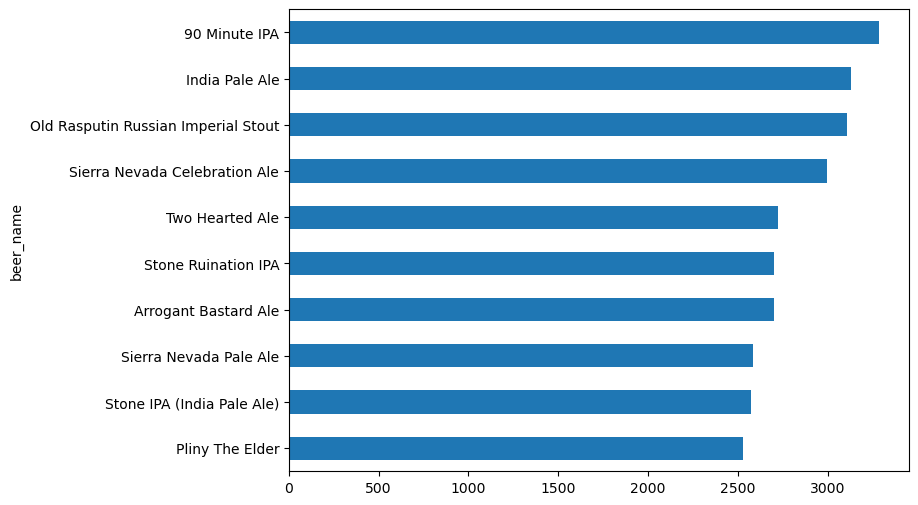

In [19]:
#nom de bière les plus testées
beer_styles = df['beer_name'].value_counts().nlargest(n=10)
print(beer_styles)

plt.figure(figsize=(8,6))
beer_styles_top_n = df['beer_name'].value_counts().nlargest(n=10)
beer_styles_top_n.sort_values(inplace=True)
beer_styles_top_n.plot.barh()

# Top 10 des brasseries les plus testées

brewery_name
Boston Beer Company (Samuel Adams)    39438
Dogfish Head Brewery                  33829
Stone Brewing Co.                     33053
Sierra Nevada Brewing Co.             28746
Bell's Brewery, Inc.                  25189
Rogue Ales                            24079
Founders Brewing Company              20000
Victory Brewing Company               19473
Lagunitas Brewing Company             16832
Avery Brewing Company                 16105
Name: count, dtype: int64


<Axes: ylabel='brewery_name'>

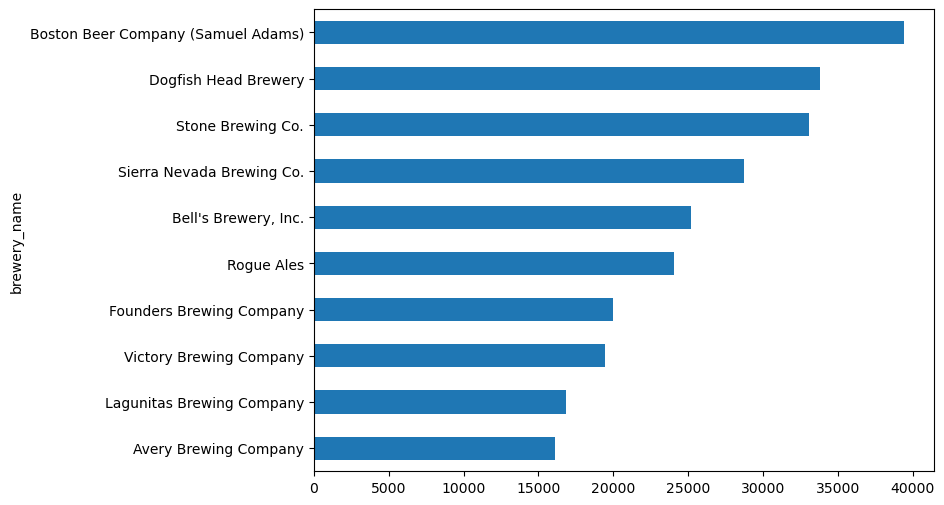

In [20]:
#brasserie testées les plus fréquentes
beer_styles = df['brewery_name'].value_counts().nlargest(n=10)
print(beer_styles)

plt.figure(figsize=(8,6))
beer_styles_top_n = df['brewery_name'].value_counts().nlargest(n=10)
beer_styles_top_n.sort_values(inplace=True)
beer_styles_top_n.plot.barh()

# Top 10 des styles de bières les mieux notés

In [39]:
beer_style_ratings = df.groupby('beer_style')['review_overall'].mean().sort_values(ascending=False).reset_index()
fig = px.bar(beer_style_ratings, y='beer_style', x='review_overall', orientation='h', title='Moyenne des notes globales par style de bières')
fig.update_xaxes(title_text='Moyenne des Note globale')
fig.update_yaxes(title_text='Style de bière')
fig.update_yaxes(range=[0,10])
fig.show()

In [40]:
beer_style_ratings = df.groupby('beer_name')['review_overall'].mean().sort_values(ascending=False).reset_index()
fig = px.bar(beer_style_ratings, y='beer_name', x='review_overall', orientation='h', title='Moyenne des notes globales par bière')
fig.update_xaxes(title_text='Moyenne des Note globale')
fig.update_yaxes(title_text='Nom de la bière')
fig.update_yaxes(range=[0,10])
fig.show()

1/ Le style de bière ayant eu le nombre le plus important de critiques : American IPA

2/ Le nom de la bière la plus testée : 90 Minute IPA

3/ La brasserie la plus souvent testée : Boston Beer Company (Samuel Adams)


***--> Nom du style de bière le mieux noté : American Wild Ale <--***






In [ ]:
#mais en faisant cela je ne ressort que les bières qui ont une note moyenne de 5. c'est peut-être pas représentatif car j'ai peut être qu'une seule critique !

In [42]:
Best_beers=df[['beer_name', 'review_overall']]\
    .pivot_table(index="beer_name", aggfunc=("count",'mean','median'))

Best_beers
#la preuve ci-dessous


review_overall                 
                                          count      mean median
beer_name                                                       
! (Old Ale)                                   1  4.000000   4.00
"100"                                         5  4.000000   4.00
"100" Pale Ale                                1  4.000000   4.00
"12"  Belgian Golden Strong Ale               2  4.000000   4.00
"33" Export                                   3  3.000000   3.00
...                                         ...       ...    ...
Žamberecký Kanec Imperial Stout              2  3.750000   3.75
Ω-naught (Omeganaught)                        3  4.166667   4.00
“Chewy” Double IPA                            1  2.500000   2.50
横須賀ビアサケ (Yokosuka Biasake)                    1  4.000000   4.00
葉山ビール (Hayama Beer)                           1  4.000000   4.00

[56847 rows x 3 columns]

## And the best beer is ............................... ##


In [ ]:
#pour considérer la meilleure bière, je dois prendre une bière qui a reçu un certain nombre de critiques pour que sa note soit valable et représentative 
# il faudrait donc que je lie le nombre de répétition/moyenne/médiane ? =pivot_table (tableau croisé dynamique)
Best_beers = df[['beer_name','review_overall']]\
    .pivot_table(index="beer_name", aggfunc=("count",'mean','median'))

#on groupe toutes les lignes comprenant des caractères ayant les mêmes valeurs, avec comme séparateur _
Best_beers.columns = Best_beers.columns.to_series().str.join('_')
#mes valeurs ne seront plus dans le même ordre (reset_index)
Best_beers.reset_index()

# Filtrer décroissant et je prends en compte que si j'ai un minimum de répétition
Best_beers = Best_beers.query('review_overall_count >= 1000')\
  .sort_values('review_overall_mean', ascending=False)\
  .head(5)

# Tadaaaam
Best_beers

,review_overall_count,review_overall_mean,review_overall_median
beer_name,,,
Trappist Westvleteren 12,1272,4.617925,4.5
Pliny The Elder,2432,4.593544,4.5
Weihenstephaner Hefeweissbier,1951,4.516146,4.5
The Abyss,1366,4.447657,4.5
Sculpin India Pale Ale,1295,4.435521,4.5


--> Avec 1272 critiques, la Trappist est élue MEILLEURE BIERE par +1 millions utilisateurs de Beeradvocates (période 1998-2011)

(les variables styles de bières, nom de brasserie ont par défaut été notées plusieurs fois, je garde les mêmes éléments)

# Recherche d'un lien entre les variables quantitatives
• Tests de corrélation

• Avis global par rapport aux autres variables


In [33]:
#avec pandas
#je liste mes 5 variables numériques
factors = ["review_appearance","review_aroma","review_palate","review_taste", "review_overall"]

#Créer ma table de corrélation 
corr_metrics = df[factors].corr()
corr_metrics.style.background_gradient(cmap='Blues')

,review_appearance,review_aroma,review_palate,review_taste,review_overall
review_appearance,1.000000,0.560000,0.570000,0.550000,0.500000
review_aroma,0.560000,1.000000,0.620000,0.720000,0.620000
review_palate,0.570000,0.620000,1.000000,0.730000,0.700000
review_taste,0.550000,0.720000,0.730000,1.000000,0.790000
review_overall,0.500000,0.620000,0.700000,0.790000,1.000000


• Le goût est le facteur qui influe le plus sur la note générale

• Vient ensuite l'arôme et le palais

• L'apparence de la bière est le facteur qui semble le moins déterminant dans la note générale



